In [20]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt 

In [21]:
data = pd.read_csv('./train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
data = np.array(data)
m, n = data.shape

np.random.shuffle(data)

split = int(0.8 * m)
train_data = data[:split]
test_data  = data[split:]

# fix: use [:, 1:] and [:, 0] to slice columns, not rows
X_train = train_data[:, 1:].T / 255.0   # shape (784, n_train), normalized
y_train = train_data[:, 0]               # shape (n_train,)

X_val   = test_data[:, 1:].T / 255.0    # shape (784, n_val)
Y_val   = test_data[:, 0]               # shape (n_val,)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape},   Y_val:   {Y_val.shape}')

X_train: (784, 33600), y_train: (33600,)
X_val:   (784, 8400),   Y_val:   (8400,)


In [23]:
def initialize_parameters():
    W1 = np.random.rand(10, 784) - 0.5
    B1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    B2 = np.random.rand(10, 1) - 0.5
    return W1, B1, W2, B2

def ReLU(X):
    return np.maximum(X, 0)

def softmax_calculator(Z):
    return np.exp(Z) / np.sum(np.exp(Z), axis=0)

def forward_propagation(W1, B1, W2, B2, X):
    Z1 = W1.dot(X) + B1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + B2
    A2 = softmax_calculator(Z2)
    return Z1, A1, Z2, A2

def one_hot_converter(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def backward_propagation(W1, B1, W2, B2, Z1, A1, Z2, A2, X, Y):
    n = Y.size
    one_hot_Y = one_hot_converter(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / n * dZ2.dot(A1.T)
    dB2 = 1 / n * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * (Z1 > 0)
    dW1 = 1 / n * dZ1.dot(X.T)
    dB1 = 1 / n * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, dB1, dW2, dB2

def update_parameters(W1, B1, W2, B2, dW1, dB1, dW2, dB2, learning_rate):
    W1 = W1 - learning_rate * dW1
    B1 = B1 - learning_rate * dB1
    W2 = W2 - learning_rate * dW2
    B2 = B2 - learning_rate * dB2
    return W1, B1, W2, B2

def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, B1, W2, B2 = initialize_parameters()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_propagation(W1, B1, W2, B2, X)
        dW1, dB1, dW2, dB2 = backward_propagation(W1, B1, W2, B2, Z1, A1, Z2, A2, X, Y)
        W1, B1, W2, B2 = update_parameters(W1, B1, W2, B2, dW1, dB1, dW2, dB2, alpha)

        if i % 20 == 0:
            print(f'Iteration: {i}, Accuracy: {get_accuracy(get_predictions(A2), Y):.4f}')

    return W1, B1, W2, B2

In [24]:
W1, B1, W2, B2 = gradient_descent(X_train, y_train, alpha=0.1, iterations=500)

Iteration: 0, Accuracy: 0.1023
Iteration: 20, Accuracy: 0.2726
Iteration: 40, Accuracy: 0.3893
Iteration: 60, Accuracy: 0.4900
Iteration: 80, Accuracy: 0.5649
Iteration: 100, Accuracy: 0.6226
Iteration: 120, Accuracy: 0.6635
Iteration: 140, Accuracy: 0.6977
Iteration: 160, Accuracy: 0.7236
Iteration: 180, Accuracy: 0.7446
Iteration: 200, Accuracy: 0.7632
Iteration: 220, Accuracy: 0.7770
Iteration: 240, Accuracy: 0.7885
Iteration: 260, Accuracy: 0.7979
Iteration: 280, Accuracy: 0.8067
Iteration: 300, Accuracy: 0.8139
Iteration: 320, Accuracy: 0.8199
Iteration: 340, Accuracy: 0.8254
Iteration: 360, Accuracy: 0.8298
Iteration: 380, Accuracy: 0.8335
Iteration: 400, Accuracy: 0.8369
Iteration: 420, Accuracy: 0.8399
Iteration: 440, Accuracy: 0.8432
Iteration: 460, Accuracy: 0.8456
Iteration: 480, Accuracy: 0.8479


Predicted label:  [1]
Actual label:  1


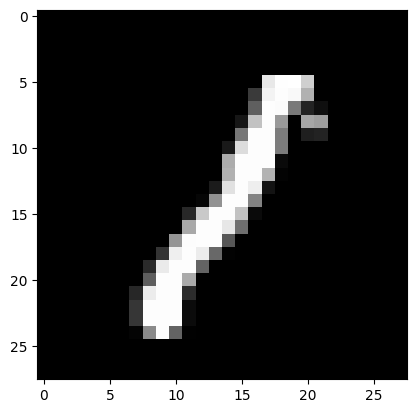

In [25]:
val_index = 560
Z1val, A1val, Z2val, A2val = forward_propagation(W1, B1, W2, B2, X_val[:, val_index, None])
print("Predicted label: ", get_predictions(A2val))
print("Actual label: ", Y_val[val_index])

image_array = X_val[:, val_index].reshape(28, 28)
plt.imshow(image_array, cmap='gray')
plt.show()

In [26]:
Z1val, A1val, Z2val, A2val = forward_propagation(W1, B1, W2, B2, X_val)
val_acc = get_accuracy(get_predictions(A2val), Y_val)
print("Validation accuracy = ", val_acc)

Validation accuracy =  0.8551190476190477
